The objective of this notebook is to find the total number of particles N between 1 and 5000 um using a cumulative sum and to compare different binning methods while comparing the error on N (number of particles in 1-5000 range) and on slope :

- optimal bin size (generated by the notebook Visual slope and intercept)
- small bin size compared to optimal bin size
- medium bin size compared to optimal bin size
- step = step * 1,5
- step = step * 2
- step = step * 3
- step = bin edge / 2
- step = step + step/2

(no reason but in practice, it has to be changed depending on the  lower LOD and n - number of particles in LODs range)

In [1]:
import numpy as np                       
import matplotlib.pyplot as plt 
from scipy.stats import linregress
import pandas as pd

In [2]:
def sample_power_law(xmin_spl,xmax_spl,b_spl,distribution_spl):
    
    """ This function samples particle size following power law distibution """
    
    exponent = b_spl + 1
    norm = (xmax_spl**exponent - xmin_spl**exponent)
    MP_size = (distribution_spl * norm + xmin_spl**exponent) ** (1 / exponent)
    return MP_size

In [3]:
def simulated_sampling(xmin_ss, xmax_ss, LOD_min_ss,LOD_max_ss, b_ss, samples_ss):
    
    """ Returns the distribution of MP sizes within the LOD interval sampled from MP 1-5000 distribution. """
    
    part_total = sample_power_law(xmin_ss, xmax_ss, b_ss, samples_ss)
    part_dispo = part_total[(part_total > LOD_min_ss) & (part_total < LOD_max_ss)]

    if len(part_dispo) == 0:
        print('Problem: there are no particles in the LOD range',LOD_min_ss,LOD_max_ss)
        return np.array([]) 

    size_distribution = np.sort(part_dispo)

    return size_distribution
    

In [4]:
# Binning and cumulative sum
def cumulative_sum(bins_cs, samplings_cs):
    """ Bins particles into chosen bins. Plots cumulative sum with dependance on lower bin limit.
        Returns cumulative sum counts in each bin for all sampling campaigns.  """

    lower_bin_limits = bins_cs
    cumulative_counts_all_samplings = []
    for i in range(len(samplings_cs)):
        cumulative_counts = np.array([(samplings_cs[i] >= limit).sum() for limit in lower_bin_limits])
        cumulative_counts_all_samplings.append(cumulative_counts)
        if i == 0: # For visualisation - enables to define the number of bins used for linear regression 
            fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 5))

            ax1.plot(lower_bin_limits, cumulative_counts, marker='o')
            ax1.set_xlabel('Lower bin limit')
            ax1.set_ylabel("Cumulative counts")
            ax1.set_title('Normal distribution')

            ax2.loglog(lower_bin_limits, cumulative_counts, marker='o')
            ax2.set_xlabel('Log lower bin limit')
            ax2.set_ylabel("log cumulative counts")
            ax2.set_title('Log log scale distribution')
    
    return cumulative_counts_all_samplings
    

In [5]:
def evaluation_of_binsize(minimal_bins_used, cumulative_counts_all_samplings_eb, lower_bin_limits_eb, slope_eb,number_of_particles_full_range_eb):
   
    """ Erases the tail of the distribution and computes the slope and intercept.
        Computes the difference between imposed parameters (N, slope), and the results of cumulative sum method.
        Evaluates the variability between sampling campaigns."""
    
    slopes_cumsum_all_samplings = []
    intercepts_cumsum_all_samplings = []
    slope_err_all_samplings = []
    N_all_samplings=[]
    N_err=[]

    for i in range(len(cumulative_counts_all_samplings_eb)):
        
        # Adjusting the tail
        counts = cumulative_counts_all_samplings_eb[i]
        if len(counts) < minimal_bins_used:
            print('Problem: There is not enough bins to do linear regression!', minimal_bins_used)
            continue
        counts_kept = counts[:minimal_bins_used]
        bins_kept = lower_bin_limits_eb[:minimal_bins_used]
        if counts_kept[-1] < 1:
            print('Problem: There is not enough particles in the last bin')
            continue
            
        # Finding slope & intercept of cumulative distribution
        log_bins = np.log10(bins_kept)
        log_counts = np.log10(counts_kept)
        slope_cumsum, intercept_cumsum, *_ = linregress(log_bins, log_counts) ### *_ ignores following variables
        slopes_cumsum_all_samplings.append(slope_cumsum)
        intercepts_cumsum_all_samplings.append(intercept_cumsum)
    

        # Comparing with initial slope
        slope = slope_cumsum - 1
        slope_err = slope - slope_eb
        slope_err_all_samplings.append(slope_err)

        # Computing N the total number of particles
    slopes_cumsum_all_samplings=np.array(slopes_cumsum_all_samplings)
    intercepts_cumsum_all_samplings=np.array(intercepts_cumsum_all_samplings)

    N_1 = slopes_cumsum_all_samplings*np.log10(1)+intercepts_cumsum_all_samplings
    N_5000=slopes_cumsum_all_samplings*np.log10(5000)+intercepts_cumsum_all_samplings
    N_all_samplings = 10**N_1-10**N_5000
    N_err_all_samplings=N_all_samplings-number_of_particles_full_range_eb
    mean_N = np.mean(N_all_samplings)
    mean_N_err = np.mean(N_err_all_samplings)
    err_purcentage=np.absolute(mean_N_err)*100/number_of_particles_full_range_eb
    mean_slope_err=np.mean(np.absolute(slope_err_all_samplings))
    min_slope_err=np.min(np.absolute(slope_err_all_samplings))
    max_slope_err=np.max(np.absolute(slope_err_all_samplings))
    min_max_slope_err=max_slope_err-min_slope_err
    

    slope_err_all_samplings = np.abs(slope_err_all_samplings)
    return mean_N, mean_N_err, err_purcentage, mean_slope_err, min_slope_err, max_slope_err, min_max_slope_err
    

In [6]:
slope_th = -1.5

# MP range
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = 10
LOD_high = 4500

# Sampling                    
sampling_campaigns = 200                          # number of samplings
number_of_particles_full_range = 1000        # number of particles over the whole range

# Multiple sampling campaigns
all_samplings=[]
for i in range(sampling_campaigns):
    random_sequence = np.random.uniform(0, 1, number_of_particles_full_range)
    size_distribution=simulated_sampling(xmin_ss=xmin, xmax_ss=xmax, LOD_min_ss=LOD_low,LOD_max_ss=LOD_high, b_ss=slope_th, samples_ss=random_sequence)
    all_samplings.append(size_distribution)
    
mean_slopes=[]
min_slopes=[]
max_slopes=[]
mean_differences=[]
min_differences=[]
max_differences=[]


### Optimal bin size

In [7]:
step = 40

bin_length=[]
bins_edges_all=[]
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    bin_length.append(next_step)
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step=step  # same step

bins_edges_all = edges

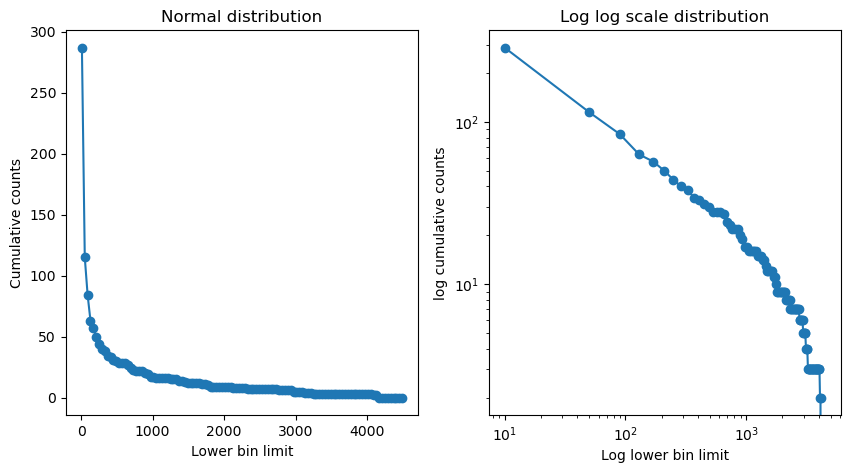

In [8]:
cumulative_counts_all_samplings=cumulative_sum(bins_cs=bins_edges_all,samplings_cs=all_samplings)


In [9]:
optimal_bins=evaluation_of_binsize(minimal_bins_used=5,
                    cumulative_counts_all_samplings_eb=cumulative_counts_all_samplings, lower_bin_limits_eb=bins_edges_all,
                    number_of_particles_full_range_eb=number_of_particles_full_range, slope_eb=slope_th)


In [10]:
optimal_binsize=pd.DataFrame({
    'Bin size' : ['Big bin size'],
    'Calulated N' : optimal_bins[0],
    'N error' : optimal_bins[1],
    '% error on N' : optimal_bins[2],
    'Slope error' : optimal_bins[3],
    'Min slope error': optimal_bins[4],
    'Max slope error': optimal_bins[5],
    'Min Max difference':optimal_bins[6]
})
optimal_binsize

,Bin size,Calulated N,N error,% error on N,Slope error,Min slope error,Max slope error,Min Max difference
0,Big bin size,1101.714778,101.714778,10.171478,0.058826,0.000212,0.178735,0.178523


### Small regular bin size & medium regular bin size

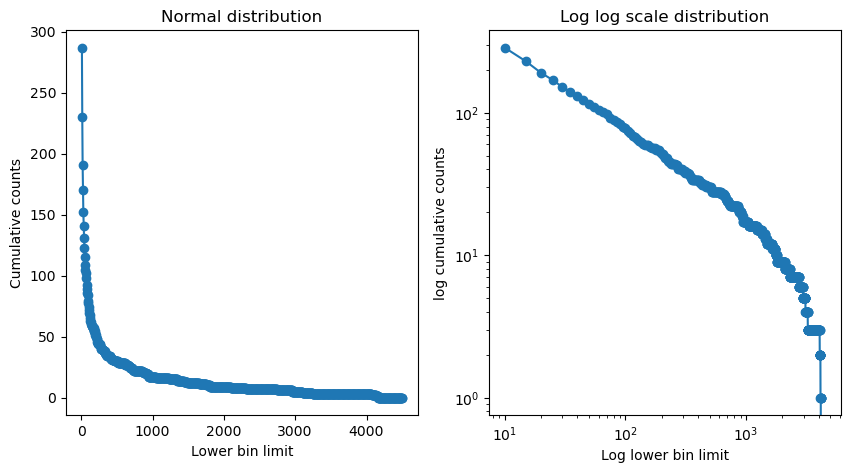

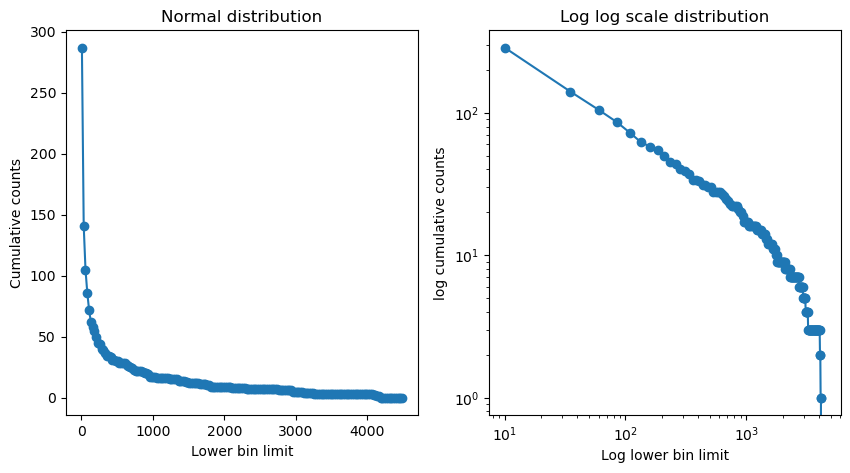

In [11]:
# Small bin size
step = 5 

bin_length=[]
bins_edges_all=[]
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    bin_length.append(next_step)
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step=step  # same step

bins_edges_all_small = edges

# Medium bi size
step = 25

bin_length=[]
bins_edges_all=[]
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    bin_length.append(next_step)
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step=step  # same step

bins_edges_all_medium = edges

cumulative_counts_all_samplings_small=cumulative_sum(bins_cs=bins_edges_all_small,samplings_cs=all_samplings)
cumulative_counts_all_samplings_medium=cumulative_sum(bins_cs=bins_edges_all_medium,samplings_cs=all_samplings)


In [12]:
small_bins=evaluation_of_binsize(minimal_bins_used=10,
                    cumulative_counts_all_samplings_eb=cumulative_counts_all_samplings_small, lower_bin_limits_eb=bins_edges_all_small,
                    number_of_particles_full_range_eb=number_of_particles_full_range, slope_eb=slope_th)
medium_bins=evaluation_of_binsize(minimal_bins_used=6,
                    cumulative_counts_all_samplings_eb=cumulative_counts_all_samplings_medium, lower_bin_limits_eb=bins_edges_all_medium,
                    number_of_particles_full_range_eb=number_of_particles_full_range, slope_eb=slope_th)

small_binsize=pd.DataFrame({
    'Bin size' : ['Small bin size'],
    'Calulated N' : small_bins[0],
    'N error' : small_bins[1],
    '% error on N' : small_bins[2],
    'Slope error' : small_bins[3],
    'Min slope error': small_bins[4],
    'Max slope error': small_bins[5],
    'Min Max difference':small_bins[6]
})

medium_binsize=pd.DataFrame({
    'Bin size' : ['Medium bin size'],
    'Calulated N' : medium_bins[0],
    'N error' : medium_bins[1],
    '% error on N' : medium_bins[2],
    'Slope error' : medium_bins[3],
    'Min slope error': medium_bins[4],
    'Max slope error': medium_bins[5],
    'Min Max difference':medium_bins[6]
})

recap_table=pd.concat([optimal_binsize, small_binsize, medium_binsize], ignore_index=True)
recap_table


,Bin size,Calulated N,N error,% error on N,Slope error,Min slope error,Max slope error,Min Max difference
0,Big bin size,1101.714778,101.714778,10.171478,0.058826,0.000212,0.178735,0.178523
1,Small bin size,1065.814623,65.814623,6.581462,0.050363,0.000202,0.204199,0.203998
2,Medium bin size,1094.627347,94.627347,9.462735,0.056302,0.000448,0.197236,0.196788


### step = step * 1,5

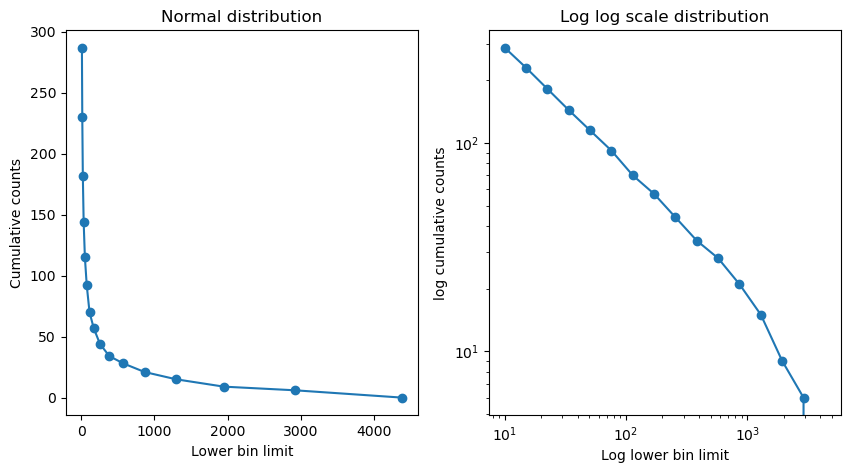

In [13]:
step = 5

bin_length=[]
bins_edges_all=[]
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    bin_length.append(next_step)
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step *= 1.5  
bins_edges_all = edges

cumulative_counts_all_samplings=cumulative_sum(bins_cs=bins_edges_all,samplings_cs=all_samplings)


In [14]:
step_1_5_bins=evaluation_of_binsize(minimal_bins_used=8,
                    cumulative_counts_all_samplings_eb=cumulative_counts_all_samplings, lower_bin_limits_eb=bins_edges_all,
                    number_of_particles_full_range_eb=number_of_particles_full_range, slope_eb=slope_th)

step_1_5_binsize=pd.DataFrame({
    'Bin size' : ['step*1.5'],
    'Calulated N' : step_1_5_bins[0],
    'N error' : step_1_5_bins[1],
    '% error on N' : step_1_5_bins[2],
    'Slope error' : step_1_5_bins[3],
    'Min slope error': step_1_5_bins[4],
    'Max slope error': step_1_5_bins[5],
    'Min Max difference':step_1_5_bins[6]
})
recap_table=pd.concat([recap_table, step_1_5_binsize], ignore_index=True)
recap_table


,Bin size,Calulated N,N error,% error on N,Slope error,Min slope error,Max slope error,Min Max difference
0,Big bin size,1101.714778,101.714778,10.171478,0.058826,0.000212,0.178735,0.178523
1,Small bin size,1065.814623,65.814623,6.581462,0.050363,0.000202,0.204199,0.203998
2,Medium bin size,1094.627347,94.627347,9.462735,0.056302,0.000448,0.197236,0.196788
3,step*1.5,1115.635602,115.635602,11.563560,0.060740,0.000222,0.199147,0.198924


### step = step * 2

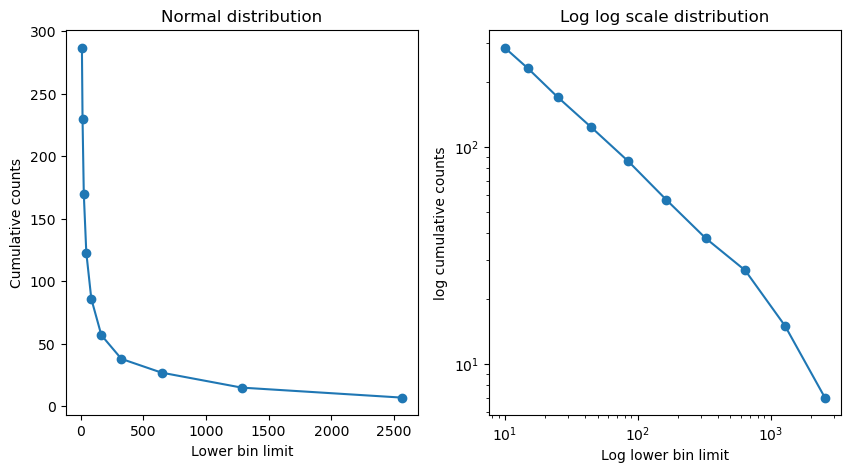

In [15]:
step = 5

bin_length=[]
bins_edges_all=[]
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    bin_length.append(next_step)
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step *= 2. 
bins_edges_all = edges

cumulative_counts_all_samplings=cumulative_sum(bins_cs=bins_edges_all,samplings_cs=all_samplings)


In [16]:
step_2=evaluation_of_binsize(minimal_bins_used=5,
                    cumulative_counts_all_samplings_eb=cumulative_counts_all_samplings, lower_bin_limits_eb=bins_edges_all,
                    number_of_particles_full_range_eb=number_of_particles_full_range, slope_eb=slope_th)

step_2_binsize=pd.DataFrame({
    'Bin size' : ['step*2'],
    'Calulated N' : step_2[0],
    'N error' : step_2[1],
    '% error on N' : step_2[2],
    'Slope error' : step_2[3],
    'Min slope error': step_2[4],
    'Max slope error': step_2[5],
    'Min Max difference':step_2[6]
})
recap_table=pd.concat([recap_table, step_2_binsize], ignore_index=True)
recap_table


,Bin size,Calulated N,N error,% error on N,Slope error,Min slope error,Max slope error,Min Max difference
0,Big bin size,1101.714778,101.714778,10.171478,0.058826,0.000212,0.178735,0.178523
1,Small bin size,1065.814623,65.814623,6.581462,0.050363,0.000202,0.204199,0.203998
2,Medium bin size,1094.627347,94.627347,9.462735,0.056302,0.000448,0.197236,0.196788
3,step*1.5,1115.635602,115.635602,11.563560,0.060740,0.000222,0.199147,0.198924
4,step*2,1078.459178,78.459178,7.845918,0.051162,0.000066,0.220178,0.220111


### step = step * 3

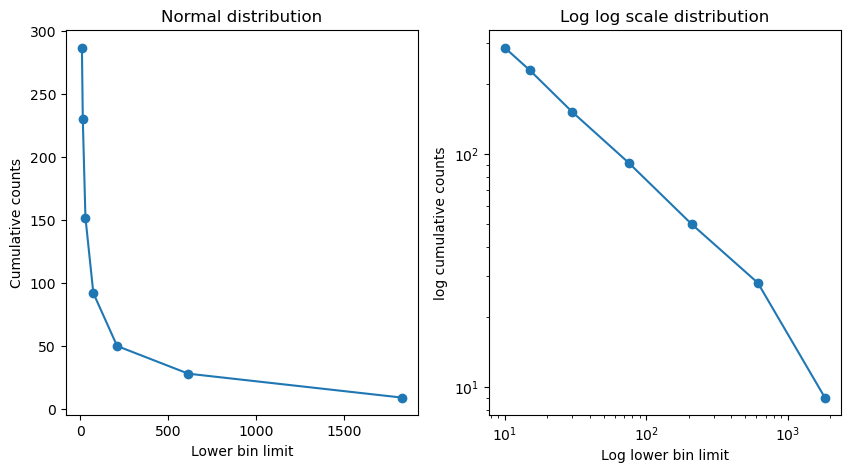

In [17]:
step = 5

bin_length=[]
bins_edges_all=[]
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    bin_length.append(next_step)
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step *= 3. 
bins_edges_all = edges

cumulative_counts_all_samplings=cumulative_sum(bins_cs=bins_edges_all,samplings_cs=all_samplings)


In [18]:
step_3=evaluation_of_binsize(minimal_bins_used=4, 
                    cumulative_counts_all_samplings_eb=cumulative_counts_all_samplings, lower_bin_limits_eb=bins_edges_all,
                    number_of_particles_full_range_eb=number_of_particles_full_range, slope_eb=slope_th)

step_3_binsize=pd.DataFrame({
    'Bin size' : ['step*3'],
    'Calulated N' : step_3[0],
    'N error' : step_3[1],
    '% error on N' : step_3[2],
    'Slope error' : step_3[3],
    'Min slope error': step_3[4],
    'Max slope error': step_3[5],
    'Min Max difference':step_3[6]
})
recap_table=pd.concat([recap_table, step_3_binsize], ignore_index=True)
recap_table


,Bin size,Calulated N,N error,% error on N,Slope error,Min slope error,Max slope error,Min Max difference
0,Big bin size,1101.714778,101.714778,10.171478,0.058826,0.000212,0.178735,0.178523
1,Small bin size,1065.814623,65.814623,6.581462,0.050363,0.000202,0.204199,0.203998
2,Medium bin size,1094.627347,94.627347,9.462735,0.056302,0.000448,0.197236,0.196788
3,step*1.5,1115.635602,115.635602,11.563560,0.060740,0.000222,0.199147,0.198924
4,step*2,1078.459178,78.459178,7.845918,0.051162,0.000066,0.220178,0.220111
5,step*3,1072.494661,72.494661,7.249466,0.050387,0.000970,0.228544,0.227574


### step = edge/2

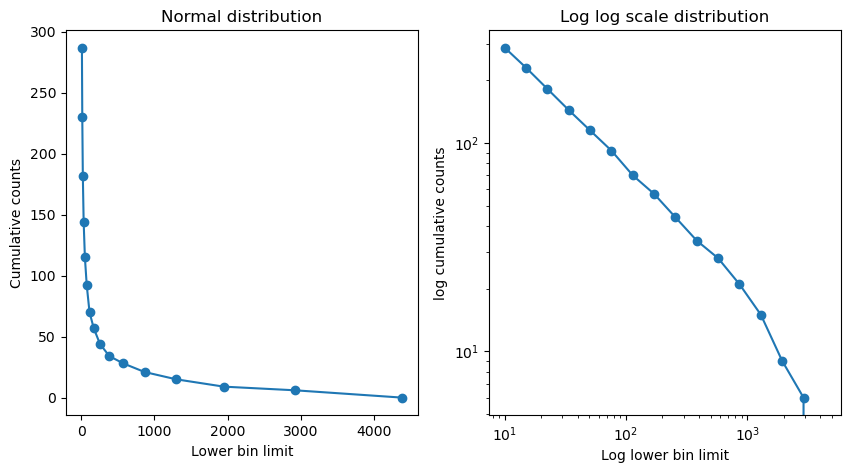

In [19]:
step = 5

bin_length=[]
bins_edges_all=[]
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    bin_length.append(next_step)
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step = current_edge / 2 
bins_edges_all = edges

cumulative_counts_all_samplings=cumulative_sum(bins_cs=bins_edges_all,samplings_cs=all_samplings)

In [20]:
edge_bins=evaluation_of_binsize(minimal_bins_used=8,
                    cumulative_counts_all_samplings_eb=cumulative_counts_all_samplings, lower_bin_limits_eb=bins_edges_all,
                    number_of_particles_full_range_eb=number_of_particles_full_range, slope_eb=slope_th)

edge_binsize=pd.DataFrame({
    'Bin size' : ['edge/2'],
    'Calulated N' : edge_bins[0],
    'N error' : edge_bins[1],
    '% error on N' : edge_bins[2],
    'Slope error' : edge_bins[3],
    'Min slope error': edge_bins[4],
    'Max slope error': edge_bins[5],
    'Min Max difference':edge_bins[6]
})
recap_table=pd.concat([recap_table, edge_binsize], ignore_index=True)
recap_table


,Bin size,Calulated N,N error,% error on N,Slope error,Min slope error,Max slope error,Min Max difference
0,Big bin size,1101.714778,101.714778,10.171478,0.058826,0.000212,0.178735,0.178523
1,Small bin size,1065.814623,65.814623,6.581462,0.050363,0.000202,0.204199,0.203998
2,Medium bin size,1094.627347,94.627347,9.462735,0.056302,0.000448,0.197236,0.196788
3,step*1.5,1115.635602,115.635602,11.563560,0.060740,0.000222,0.199147,0.198924
4,step*2,1078.459178,78.459178,7.845918,0.051162,0.000066,0.220178,0.220111
5,step*3,1072.494661,72.494661,7.249466,0.050387,0.000970,0.228544,0.227574
6,edge/2,1115.635602,115.635602,11.563560,0.060740,0.000222,0.199147,0.198924


### Typical binning in MPSizeBase

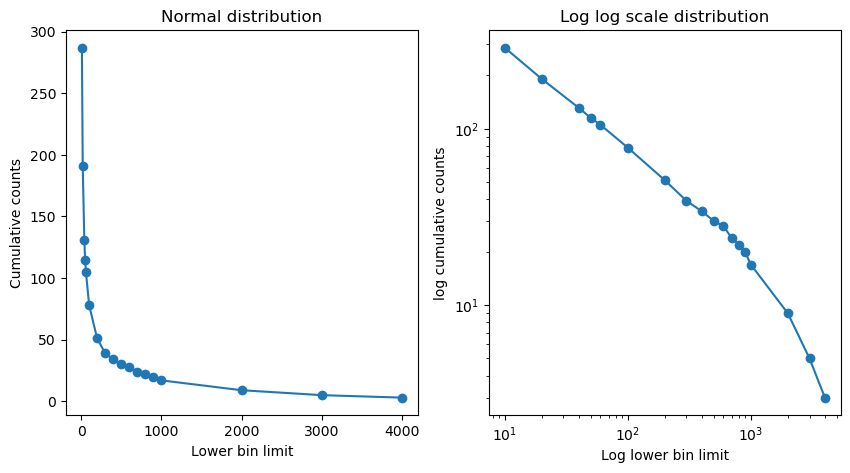

In [21]:
bins_edges_all = [10,20,40,50,60,100,200,300,400,500,600,700,800,900,1000,2000,3000,4000]

cumulative_counts_all_samplings=cumulative_sum(bins_cs=bins_edges_all,samplings_cs=all_samplings)


In [22]:
typical_bins=evaluation_of_binsize(minimal_bins_used=6,
                    cumulative_counts_all_samplings_eb=cumulative_counts_all_samplings, lower_bin_limits_eb=bins_edges_all,
                    number_of_particles_full_range_eb=number_of_particles_full_range, slope_eb=slope_th)

typical_binsize=pd.DataFrame({
    'Bin size' : ['Typical bin size'],
    'Calulated N' : typical_bins[0],
    'N error' : typical_bins[1],
    '% error on N' : typical_bins[2],
    'Slope error' : typical_bins[3],
    'Min slope error': typical_bins[4],
    'Max slope error': typical_bins[5],
    'Min Max difference':typical_bins[6]
})



In [23]:
recap_table

,Bin size,Calulated N,N error,% error on N,Slope error,Min slope error,Max slope error,Min Max difference
0,Big bin size,1101.714778,101.714778,10.171478,0.058826,0.000212,0.178735,0.178523
1,Small bin size,1065.814623,65.814623,6.581462,0.050363,0.000202,0.204199,0.203998
2,Medium bin size,1094.627347,94.627347,9.462735,0.056302,0.000448,0.197236,0.196788
3,step*1.5,1115.635602,115.635602,11.563560,0.060740,0.000222,0.199147,0.198924
4,step*2,1078.459178,78.459178,7.845918,0.051162,0.000066,0.220178,0.220111
5,step*3,1072.494661,72.494661,7.249466,0.050387,0.000970,0.228544,0.227574
6,edge/2,1115.635602,115.635602,11.563560,0.060740,0.000222,0.199147,0.198924


- Calculated N : total number of particles in range 1-5000 found by using cumulative sum method
- N error : Difference between calculated N and N imposed as parameter, meen over all sampling campaigns
- % error on N : N error in %
- Slope error : Difference between calculated slope and slope_th imposed as parameter, meen over all sampling campaigns
- Min slope error : Minimal value of slope error over all sampling campaigns
- Max slope error : Maximal value of slope error over all sampling campaigns
- Min Max difference : variability of slope over all sampling campaigns


In [24]:
print('Minimal slope error:', recap_table['Slope error'][np.argmin(np.absolute(recap_table['Slope error']))],'corresponds to:', recap_table['Bin size'][np.argmin(np.absolute(recap_table['Slope error']))])
print('Minimal min error:', recap_table['Min slope error'][np.argmin(np.absolute(recap_table['Min slope error']))],'corresponds to:', recap_table['Bin size'][np.argmin(np.absolute(recap_table['Min slope error']))])
print('Minimal max error:', recap_table['Max slope error'][np.argmin(np.absolute(recap_table['Max slope error']))],'corresponds to:', recap_table['Bin size'][np.argmin(np.absolute(recap_table['Max slope error']))])
print('Minimal Min Max difference:', recap_table['Min Max difference'][np.argmin(np.absolute(recap_table['Min Max difference']))],'corresponds to:', recap_table['Bin size'][np.argmin(np.absolute(recap_table['Min Max difference']))])
print('Minimal error on N:', recap_table['% error on N'][np.argmin(recap_table['% error on N'])],'% corresponds to:', recap_table['Bin size'][np.argmin(recap_table['% error on N'])])


Minimal slope error: 0.05036305288552351 corresponds to: Small bin size
Minimal min error: 6.640040853578277e-05 corresponds to: step*2
Minimal max error: 0.17873463884734941 corresponds to: Big bin size
Minimal Min Max difference: 0.17852275300033615 corresponds to: Big bin size
Minimal error on N: 6.581462283116302 % corresponds to: Small bin size


Since the most important error is the error on slope, the minimal max error, and the minimal error on N, the best binning seems to be the step = edge/2 pattern. 

But this result depends on the sampling parameters (slope, n, N, LOD). Neverless, we see that the error is small for all binning paterns.

If we add the typical binning pattern, corresponding to intuitive binning of patricles while keeping considered number of particles in each bin, this intuitive binning seems to have an poisitve impact on the slope computation. Thus, if authors bin particles in irregular bins, using intuition, the outcoming slope might be quite precise. 

In [25]:
recap_table=pd.concat([recap_table, typical_binsize], ignore_index=True)
recap_table

,Bin size,Calulated N,N error,% error on N,Slope error,Min slope error,Max slope error,Min Max difference
0,Big bin size,1101.714778,101.714778,10.171478,0.058826,0.000212,0.178735,0.178523
1,Small bin size,1065.814623,65.814623,6.581462,0.050363,0.000202,0.204199,0.203998
2,Medium bin size,1094.627347,94.627347,9.462735,0.056302,0.000448,0.197236,0.196788
3,step*1.5,1115.635602,115.635602,11.563560,0.060740,0.000222,0.199147,0.198924
4,step*2,1078.459178,78.459178,7.845918,0.051162,0.000066,0.220178,0.220111
5,step*3,1072.494661,72.494661,7.249466,0.050387,0.000970,0.228544,0.227574
6,edge/2,1115.635602,115.635602,11.563560,0.060740,0.000222,0.199147,0.198924
7,Typical bin size,1083.005518,83.005518,8.300552,0.052526,0.000109,0.221155,0.221046


In [26]:
print('Minimal slope error:', recap_table['Slope error'][np.argmin(np.absolute(recap_table['Slope error']))],'corresponds to:', recap_table['Bin size'][np.argmin(np.absolute(recap_table['Slope error']))])
print('Minimal min error:', recap_table['Min slope error'][np.argmin(np.absolute(recap_table['Min slope error']))],'corresponds to:', recap_table['Bin size'][np.argmin(np.absolute(recap_table['Min slope error']))])
print('Minimal max error:', recap_table['Max slope error'][np.argmin(np.absolute(recap_table['Max slope error']))],'corresponds to:', recap_table['Bin size'][np.argmin(np.absolute(recap_table['Max slope error']))])
print('Minimal Min Max difference:', recap_table['Min Max difference'][np.argmin(np.absolute(recap_table['Min Max difference']))],'corresponds to:', recap_table['Bin size'][np.argmin(np.absolute(recap_table['Min Max difference']))])
print('Minimal error on N:', recap_table['% error on N'][np.argmin(recap_table['% error on N'])],'% corresponds to:', recap_table['Bin size'][np.argmin(recap_table['% error on N'])])


Minimal slope error: 0.05036305288552351 corresponds to: Small bin size
Minimal min error: 6.640040853578277e-05 corresponds to: step*2
Minimal max error: 0.17873463884734941 corresponds to: Big bin size
Minimal Min Max difference: 0.17852275300033615 corresponds to: Big bin size
Minimal error on N: 6.581462283116302 % corresponds to: Small bin size


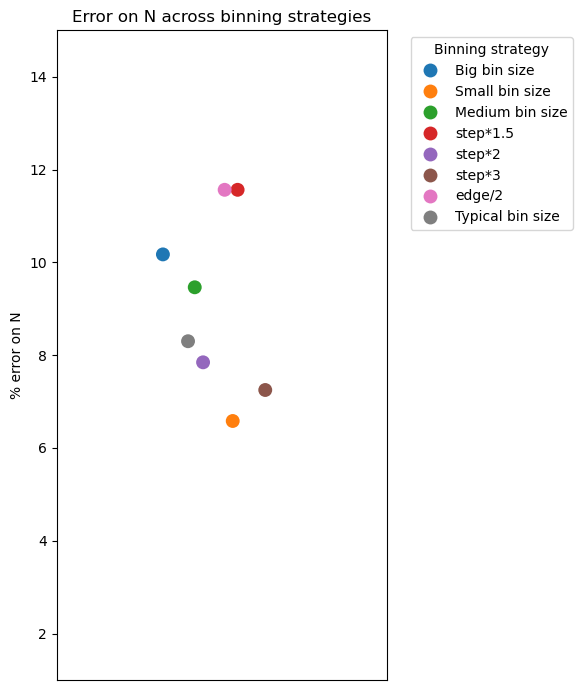

In [27]:
import seaborn as sns


plt.figure(figsize=(6, 7))
sns.stripplot(
    data=recap_table,
    y='% error on N',
    x=[0]*len(recap_table),  # Align all points on a single vertical axis
    hue='Bin size',
    palette='tab10',
    size=10,
    jitter=0.2,
    dodge=False
)

# Styling
plt.axhline(0, color='black', linestyle='--', linewidth=1)  # True value line
plt.xlabel('')  # No X-axis label
plt.xticks([])  # Remove X-axis ticks
plt.ylabel('% error on N')
plt.title('Error on N across binning strategies')

# Legend
plt.ylim(1,15)
plt.legend(title='Binning strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
